# Exploratory Data Analysis

This notebook examines the dataset from https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations. The goals of this notebook are:
1. Understand the structure and content of the dataset.
2. Identify any missing or inconsistent data.
3. Generate summary statistics and visualizations to uncover patterns and insights.

## Getting started

Import necessary libraries

In [1]:
from pathlib import Path
import os
os.chdir(str(Path(os.getcwd()).parent))
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import chess
from src.utils import fen_to_tensor, plot_planes

c:\Users\Ruslan\Desktop\Projects\Python\chessengine


Loading the dataset

In [3]:
# not reading full 16M+ dataset
df = pd.read_csv("dataset/raw/random_evals.csv", nrows=100000)

Basic info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   FEN         100000 non-null  object
 1   Evaluation  100000 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


In [5]:
df.sample(5)

,FEN,Evaluation
51247,r1bqk2r/2p4p/p1pp2p1/4Bpb1/1P6/P3PQ1P/2PP1P2/R...,+1048
42497,rnbqk2r/ppp2ppp/8/3nN3/1bB5/8/PPPP1PPP/RNBQK2R...,+272
87050,4r2r/2pkB2n/2ppq3/4p1pp/4P1b1/2PPQN2/PP1N1PPP/...,+835
13191,R7/pp3p1k/n1p3pQ/3p2P1/3P2p1/2PB2P1/PP5P/RN4K1...,#+0
71117,r4rk1/pbqnbppp/1p2pn2/2pp4/5P2/1P2PNP1/PBPPQ2P...,-71


Turning `Evaluation` column to `int`

In [6]:
df = df[~df["Evaluation"].str.contains("#")]

In [7]:
df["Evaluation"] = df["Evaluation"].astype(int)
df.sample(5)

,FEN,Evaluation
92247,r1b2rk1/pppp1ppp/2n2q2/5Q2/1P1bP3/P1N3P1/2PB1P...,-563
52350,r2q1rk1/pp1bb1pp/2n2pn1/1Bpp4/7P/3P1NB1/PPP2PP...,-189
97424,r3k2r/ppp4p/3b1Bp1/3Pp3/2B2p2/2P1nP1P/PP3P2/2K...,640
86813,1k2rb1r/p1p3p1/2ppqn2/4p1Bp/Q3P1b1/2PP1N2/PP1N...,436
78643,2r2rk1/6pp/7q/p7/P1Pp2P1/5PB1/1P3Q1P/R4RK1 b -...,582


In [8]:
df.describe()

,Evaluation
count,95139.000000
mean,12.103165
std,965.020171
min,-12783.000000
25%,-344.000000
50%,0.000000
75%,366.000000
max,9165.000000


Plotting the distribution of `Evaluation`

<Axes: ylabel='Frequency'>

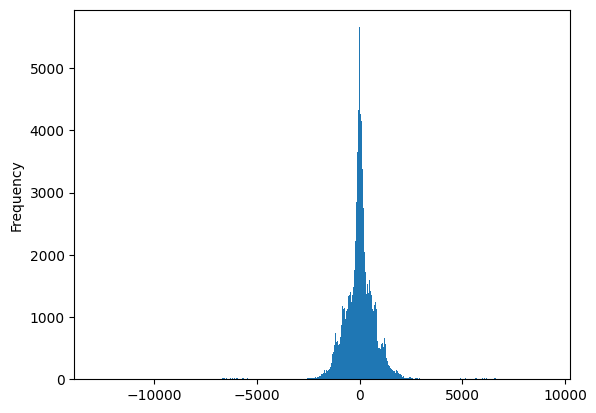

In [9]:
df['Evaluation'].plot.hist(bins=500)

Examining `FEN` column

In [10]:
df.sample(5)["FEN"].values

array(['rnbqkb1r/ppp1pppp/3p4/3nP3/2BP4/8/PPP2PPP/RNBQK1NR b KQkq - 1 4',
       '2b1r1k1/r1qnppbp/pp1p1np1/1Pp3B1/2PP4/P1N1PN1P/4BPP1/R2Q1RK1 w - - 1 13',
       'rnbqk2r/pp2ppbp/1n1p2p1/8/P1PP4/5N2/1P2QPPP/RNB1KB1R b KQkq - 2 8',
       'rnbqkbnr/pp1ppppp/8/2p5/8/P7/1PPPPPPP/RNBQKBNR w KQkq - 0 2',
       '2r1r1k1/1bq2pbp/1p3Bp1/pPp1p3/P1P5/2N1PB1P/5PP1/R2Q1RK1 w - - 1 18'],
      dtype=object)

Converting `FEN` notation to suitable **tensor**

We’ll use this fixed order:

|Board #|Description|
|:-:|:-:|
|0|white pawn|
|1|white knight|
|2|white bishop|
|3|white rook|
|4|white queen|
|5|white king|
|6|black pawn|
|7|black knight|
|8|black bishop|
|9|black rook|
|10|black queen|
|11|black king|
|12|side to move (white=1, black=0)|
|13|white king-side castling|
|14|white queen-side castling|
|15|black king-side castling|
|16|black queen-side castling|
|17|en passant square|

In [11]:
samplee = df.sample().values[0]
samplee

array(['r1bq1rk1/pp1n2bp/2p1ppp1/5n2/2PPNB2/5NP1/PP3PBP/R1Q2RK1 b - - 3 12',
       22], dtype=object)

In [12]:
planes = fen_to_tensor(samplee[0])
planes

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 1, 0],
        [1, 1, 0, ..., 1, 0, 1],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

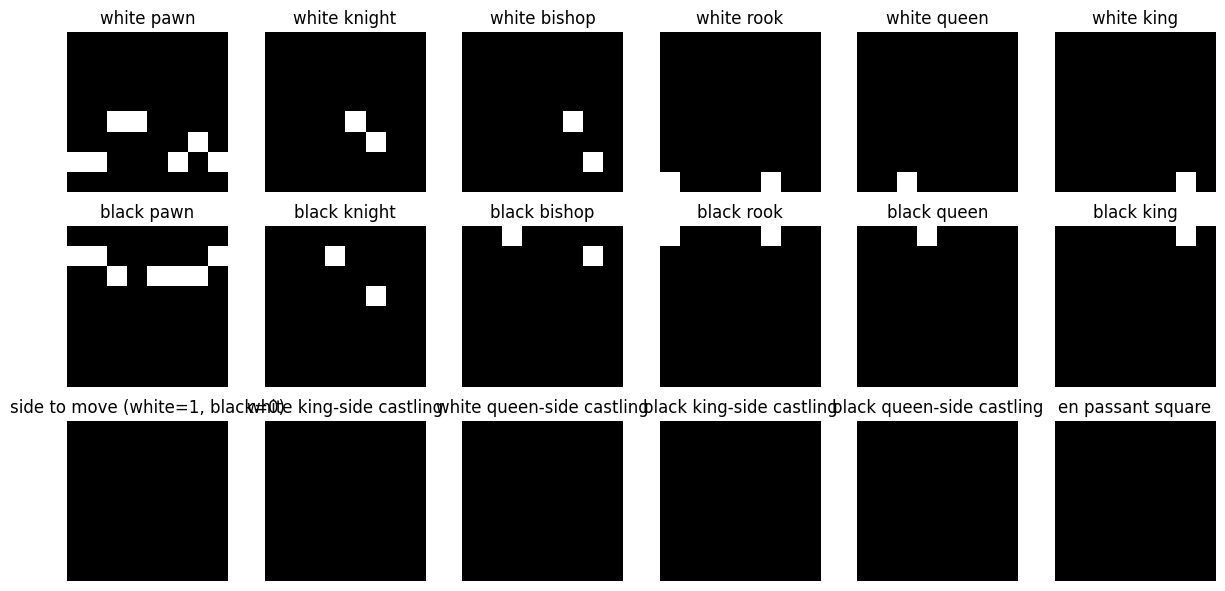

In [13]:
plot_planes(planes=planes)

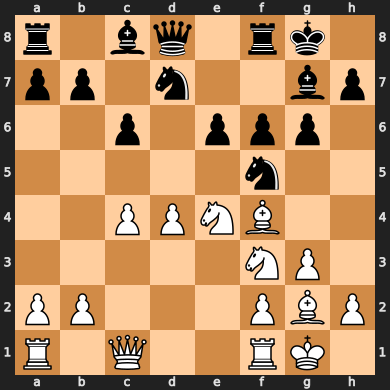

In [14]:
chess.Board(samplee[0])

In [15]:
print("Evaluation:", samplee[1])

Evaluation: 22


Examining outliers

In [16]:
position = df.sort_values(by="Evaluation", ascending=False).iloc[1]
position

FEN           rn2k1nr/p1p4p/4Bpp1/8/3P4/1Q2BN2/P1q2PPP/1R3RK...
Evaluation                                                 8958
Name: 14325, dtype: object

In [17]:
planes = fen_to_tensor(position.iloc[0])
planes

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 

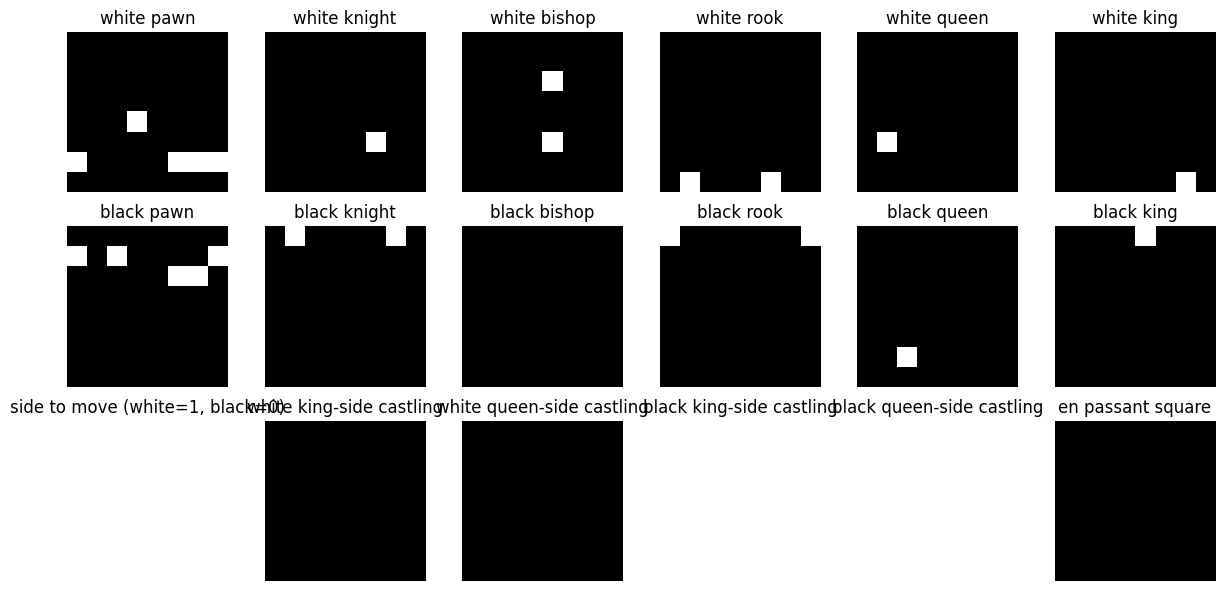

In [18]:
plot_planes(planes=planes)

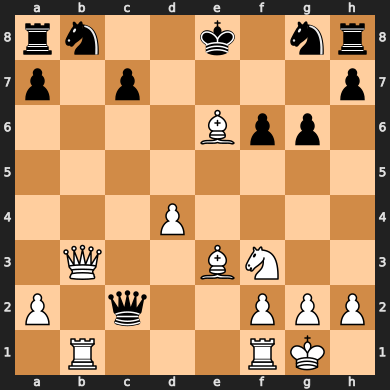

In [19]:
chess.Board(position.iloc[0])

In [20]:
print("Evaluation:", position.iloc[1])

Evaluation: 8958


## Examining `tactics_evals.csv`

This dataset contains positions primarily with tactics, hence there is more *moves-to-mate* positions

In [23]:
df = pd.read_csv("dataset/raw/tactic_evals.csv", nrows=100_000)
df.sample(5)

,FEN,Evaluation,Move
85475,r1bq2k1/ppp3pp/2n1p3/4P3/2PPnB2/1QP5/P5PP/R3KB...,+180,d8h4
58923,r3k1nr/ppp2pp1/3p3p/4N2b/N1B1P3/P6P/1P3KP1/R1B...,+313,d6e5
25954,r3k2r/4bpp1/p1p2n1p/q1p1p3/N3P3/P2PBQ1P/2P2PP1...,-386,e1e2
89796,1R4q1/p1k5/1p2p2R/3pP1rP/8/PN2nB2/1P5K/8 w - -...,+809,b8g8
87515,4rrk1/2pb1ppp/2pp4/6q1/4P3/1PNB1P1n/P1P2QPP/R3...,-986,h3f2


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   FEN         100000 non-null  object
 1   Evaluation  100000 non-null  object
 2   Move        92990 non-null   object
dtypes: object(3)
memory usage: 2.3+ MB


Don't really need the `Move` column, so dropping it

In [25]:
df.drop(columns=["Move"], inplace=True)
df.sample(5)

,FEN,Evaluation
48430,b7/2p1n1p1/pp2p3/r4kP1/5P2/1B1N4/PPP5/2K4R b -...,-801
63711,3rr1k1/ppqn1pp1/2p2b1p/3p4/3P4/P1P2N1P/1PQNRPP...,-751
67915,r5k1/1p2B1b1/p2pp1pp/8/N1P1P1nN/8/P3q1PP/4Q1RK...,-732
34676,3k2N1/p7/r2p3p/8/8/7P/5P1K/5R2 b - - 0 51,+207
51188,8/2p5/1p1kp3/8/2p1Q1P1/2P2P2/PP3RKP/2q3r1 w - ...,#-1


Splitting evaluations into `df_cp` and `df_mtm` for evaluations in centipawns and moves-to-mate respectively

In [26]:
df_cp = df[~df["Evaluation"].str.contains("#")]
df_mtm = df[df["Evaluation"].str.contains("#")]

In [27]:
df_cp.sample(5)

,FEN,Evaluation
5053,r7/5K2/4P3/5k2/5P2/6P1/8/8 w - - 1 56,+977
22890,r3k2r/pp1bbppp/4pn2/Q7/4P3/2N5/PPP2PPP/R1B1K2R...,+795
78686,r1bqk2r/p1p1nppp/8/2bp4/8/5P2/PPP1Q1PP/RNB1KB1...,+442
45694,8/2p3k1/1p5p/p5pP/P1P5/6K1/1P6/1B6 b - - 0 39,+355
94834,rnb1kbnr/ppp2ppp/8/4p3/4P2q/7P/PPPP2P1/RNBQKBN...,-775


`df_cp` is the same as what we've seen before, so examining `df_mtm`

In [28]:
df_mtm.sample(5)

,FEN,Evaluation
25634,3r2k1/p4pPp/2p5/5Q2/5P2/4P3/PPP4P/1K1q2R1 w - ...,#-1
52388,6k1/5pp1/7p/1p6/3Q4/8/1B3PPP/4r1K1 w - - 0 28,#-0
83152,5k1r/R4p2/3p1P1p/p1pP4/1rP5/1b6/6PP/6K1 w - - ...,#+2
61933,5rk1/1p1n2pp/2p5/p2p4/3P1P2/P3Pn2/1P3P1r/1RRQ2...,#-0
8328,3R2k1/pp3ppp/q3pn2/8/8/1P5P/P4PP1/5RK1 b - - 0 26,#+1


In [29]:
df_mtm["Evaluation"].value_counts()

Evaluation
#-1     5182
#+1     5050
#-0     3532
#+0     3478
#-2     1787
#+2     1684
#-3      138
#+3      116
#+4        4
#-4        2
#+15       1
#+18       1
Name: count, dtype: int64

In [30]:
mate = df[df['Evaluation'] == "#+18"].sample().iloc[0]
mate

FEN           kr6/5Qp1/3q1b1p/1b1Bp3/p7/6P1/P4P1P/2R3K1 b - ...
Evaluation                                                 #+18
Name: 3867, dtype: object

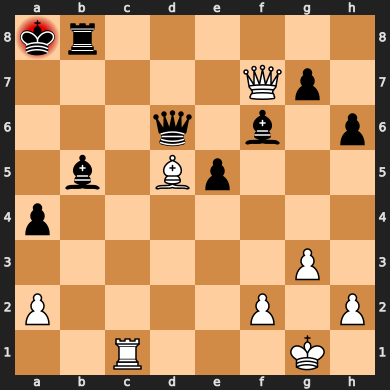

In [31]:
chess.Board(mate['FEN'])

In [32]:
df_mtm['Evaluation'].str.split("#").str[1].astype(int).max()

np.int64(18)

## Combining three dataframes into one

In [33]:
df1 = pd.read_csv("dataset/raw/chess_data.csv", nrows=30000)
df2 = pd.read_csv("dataset/raw/random_evals.csv", nrows=30000)
df3 = pd.read_csv("dataset/raw/tactic_evals.csv", nrows=30000)

In [34]:
df = pd.concat([df1, df2, df3], ignore_index=True).drop(columns=['Move'])
df.head()

,FEN,Evaluation
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,+56
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,+52
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26


Normalizing `Evaluation` column values

In [35]:
df[df["Evaluation"].str.contains("#")]["Evaluation"]

59        #+6
60        #+6
61        #+4
62        #+3
1440     #-19
         ... 
89932     #-1
89943     #+2
89944     #+1
89946     #+1
89947     #+0
Name: Evaluation, Length: 8322, dtype: object

In [36]:
def normalize(
        x: str,
        minn: int, maxx: int
    ):

    num = int(x.split("#")[1])
    if num < 0:
        return -30_000 + 29_000 * np.abs(num / minn)
    elif num > 0:
        return 30_000 - 29_000 * (num / maxx)
    return int(x.split("#")[1][0] + "30000")

In [37]:
maxx = df[df["Evaluation"].str.contains("#")]["Evaluation"].str.split("#").str[1].astype(int).max()
minn = df[df["Evaluation"].str.contains("#")]["Evaluation"].str.split("#").str[1].astype(int).min()

In [38]:
minn

np.int64(-23)

In [39]:
maxx

np.int64(21)

In [40]:
df["Evaluation_norm"] = df["Evaluation"].apply(
    lambda x: normalize(
        x,
        minn,
        maxx
    ) if "#" in x else int(x)
).apply(lambda x: np.tanh(x / 500))

In [41]:
df[df['Evaluation'] == "#+19"].sample()

,FEN,Evaluation,Evaluation_norm
6003,r3q3/6pk/2p3r1/1pn5/7N/n5P1/2Q3BP/4RR1K w - - ...,#+19,0.999999


## Examining the preprocessed dataframe

In [45]:
df = pd.read_csv("dataset/preprocessed/preprocessed.csv", nrows=None)

KeyboardInterrupt: 

In [ ]:
df.info()

In [43]:
df.Evaluation.describe()

count     90000
unique     4110
top           0
freq       3653
Name: Evaluation, dtype: object

In [44]:
df.Evaluation.hist(bins=100)

<Axes: >

Error in callback <function flush_figures at 0x000001E91541E980> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 